# 04 · Findings and pricing

What the model says, and what a team selling one race at a time should do about it.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from viz import use_style, short_track, money_axis, headline, source, SEQ, FIELD, NY, THIRD, INK, INK_2, CONTEXT
import matplotlib
use_style()
pd.set_option("display.max_columns", 20, "display.width", 140)
ROOT = Path.cwd().parent
con = duckdb.connect(str(ROOT / "data" / "nascar_2025.duckdb"), read_only=True)
from IPython.display import Image
df = pd.read_csv(ROOT / "data/processed/car_race_value.csv", dtype={"car_number": str})
V = np.load(ROOT / "data/processed/mc_values.npy")
bm = pd.read_csv(ROOT / "data/processed/backmarker_run_by_race.csv")
S = json.loads((ROOT / "data/processed/summary.json").read_text())

## Finding 1 · Camera time is steeply concentrated at the front

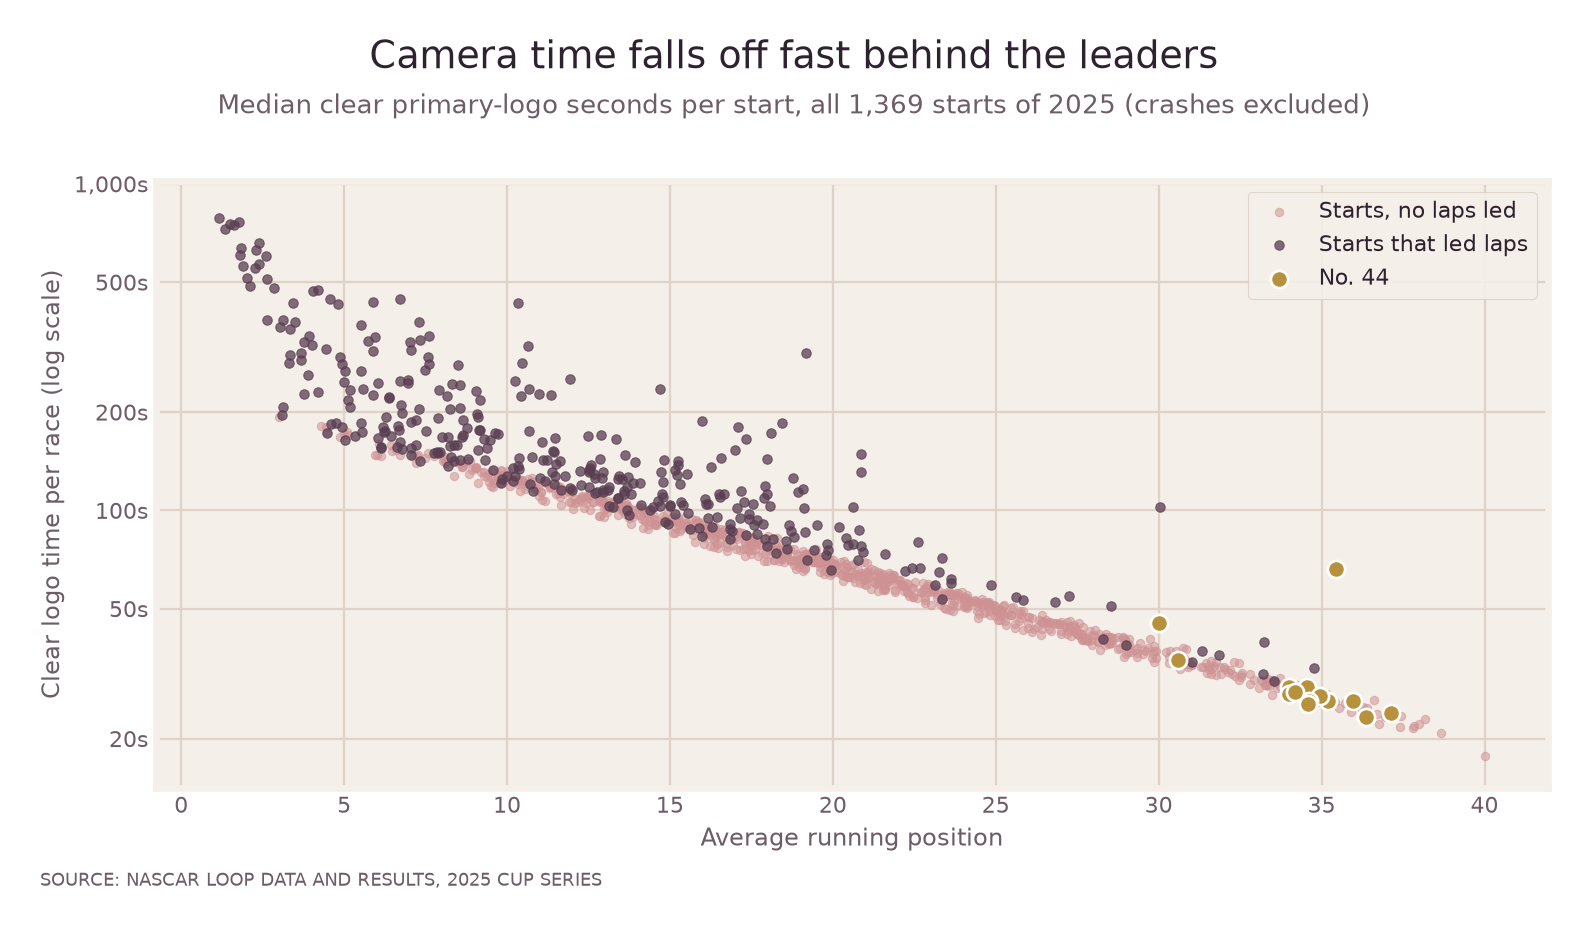

Car that led the most laps: median 473 clear seconds per race
Typical backmarker:         median 36 clear seconds per race


In [2]:
display(Image(str(ROOT / "images/exposure_curve.png"), width=520))
print(f"Car that led the most laps: median {S['leader_vs_backmarker_seconds']['most_laps_led_median_sec']:.0f} clear seconds per race")
print(f"Typical backmarker:         median {S['leader_vs_backmarker_seconds']['backmarker_median_sec']:.0f} clear seconds per race")

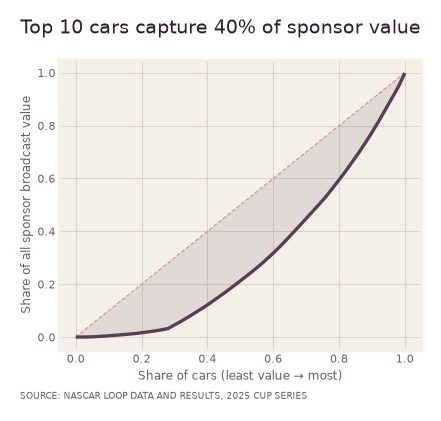

In [3]:
car_idx = df.groupby("car_number").indices
carval = np.array([V[:, i].sum(1) for i in car_idx.values()]).T
med = np.sort(np.median(carval / carval.sum(1, keepdims=True), 0))
cum = np.insert(np.cumsum(med), 0, 0); x = np.linspace(0, 1, len(cum))
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.plot([0, 1], [0, 1], color=CONTEXT, lw=1, ls="--"); ax.plot(x, cum, color=FIELD); ax.fill_between(x, cum, x, color=FIELD, alpha=0.12)
ax.set_xlabel("Share of cars (least value → most)"); ax.set_ylabel("Share of all sponsor broadcast value")
headline(fig, f"Top 10 cars capture {S['concentration']['top10_share']:.0%} of sponsor value")
source(fig); plt.show()

## Finding 2 · The broadcast window matters more than the finish

A typical backmarker run (bottom quarter of the field, no laps led, no crash) gets about the same clear seconds everywhere. The audience is what changes.

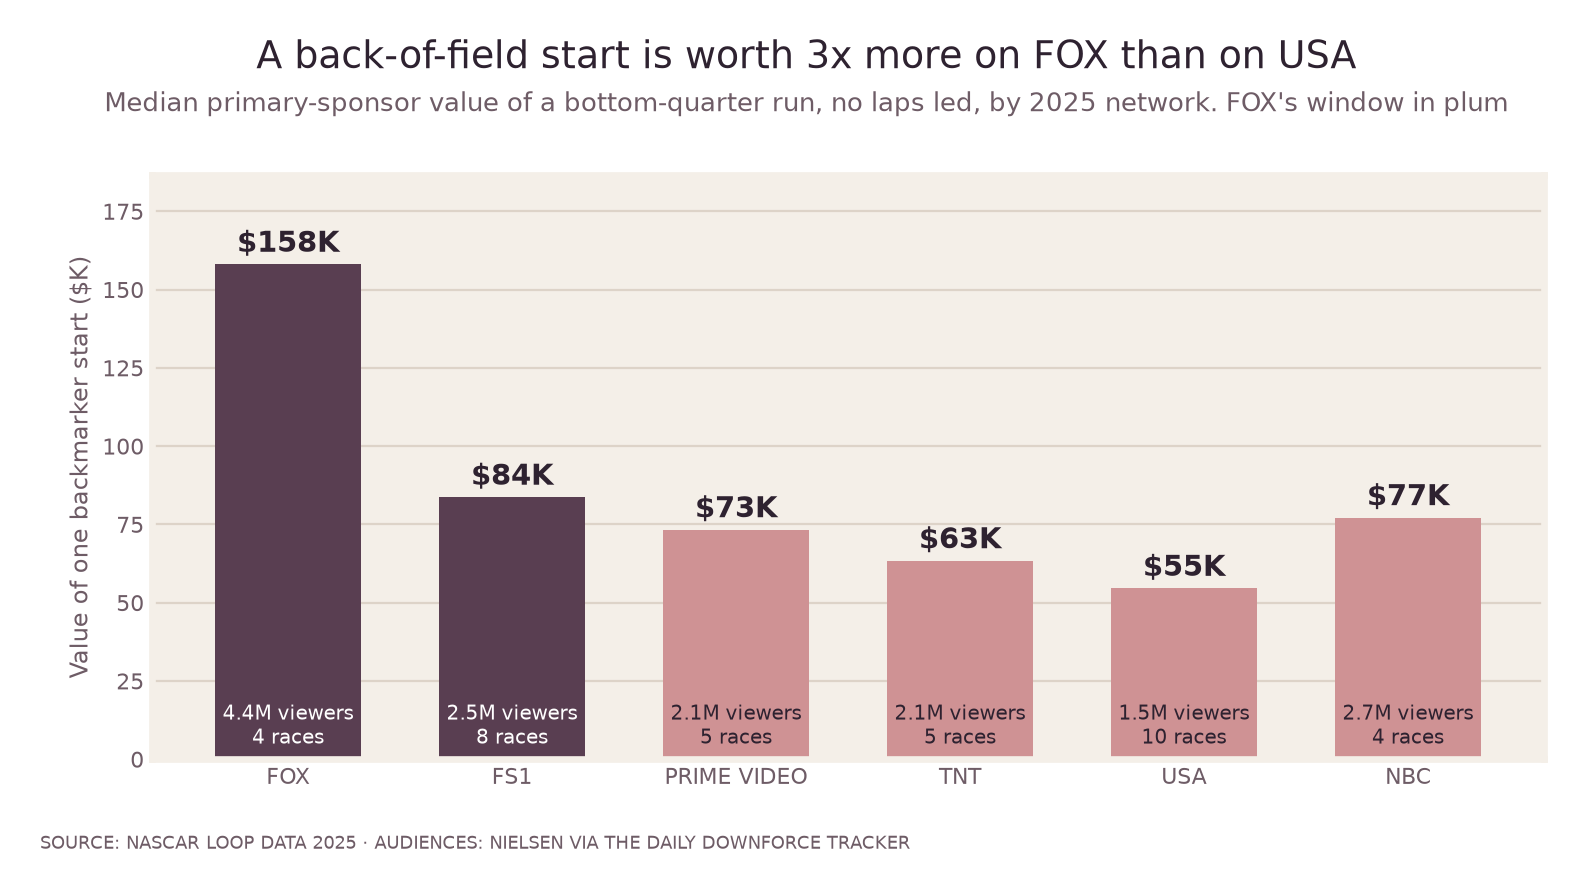

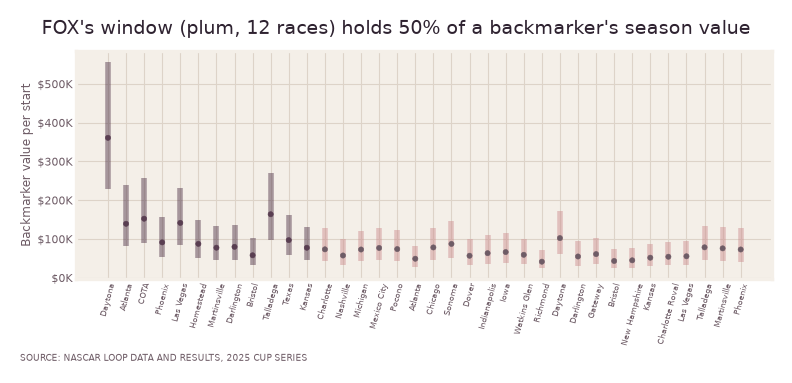

In [4]:
display(Image(str(ROOT / "images/network_window.png"), width=520))
b = bm.sort_values("race_date").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 3.6))
fox = b.broadcaster.isin(["FOX", "FS1"])
ax.vlines(range(len(b)), b.value_p10, b.value_p90, color=np.where(fox, FIELD, CONTEXT), lw=5, alpha=0.5)
ax.scatter(range(len(b)), b.value_p50, color=np.where(fox, FIELD, INK_2), s=22, zorder=3)
ax.set_xticks(range(len(b)), [short_track(t) for t in b.track_name], rotation=75, fontsize=7)
money_axis(ax, "y", "K"); ax.set_ylabel("Backmarker value per start")
headline(fig, f"FOX's window (plum, {int(fox.sum())} races) holds {S['fox_window_share_of_backmarker_value']:.0%} of a backmarker's season value")
source(fig); plt.show()

### The network effect, tested on real data

The pricing finding rests on one measured input: audience size by network. These tests use only the 36 races' Nielsen audiences, with no model assumptions. A Kruskal–Wallis test asks whether audiences differ by network at all. An OLS regression on log(viewers), with track type as a control and robust (HC3) standard errors, measures how large each network's audience is relative to USA. Networks air in fixed parts of the season, so the network term also carries some time-of-year effect; the NBC vs. USA comparison, which share the same fall stretch, is the cleanest check on that.

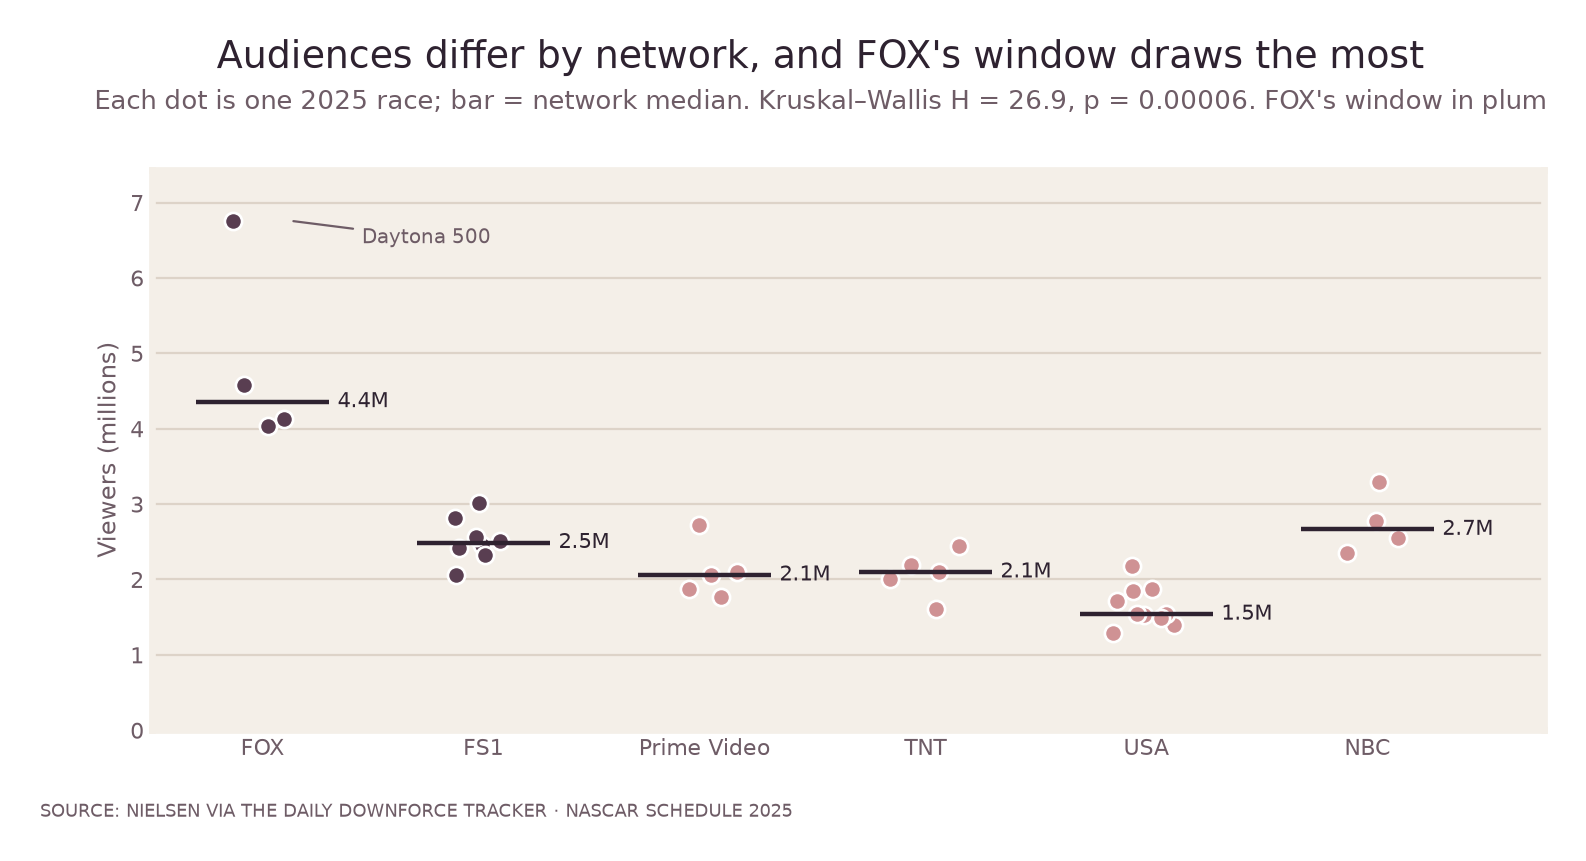

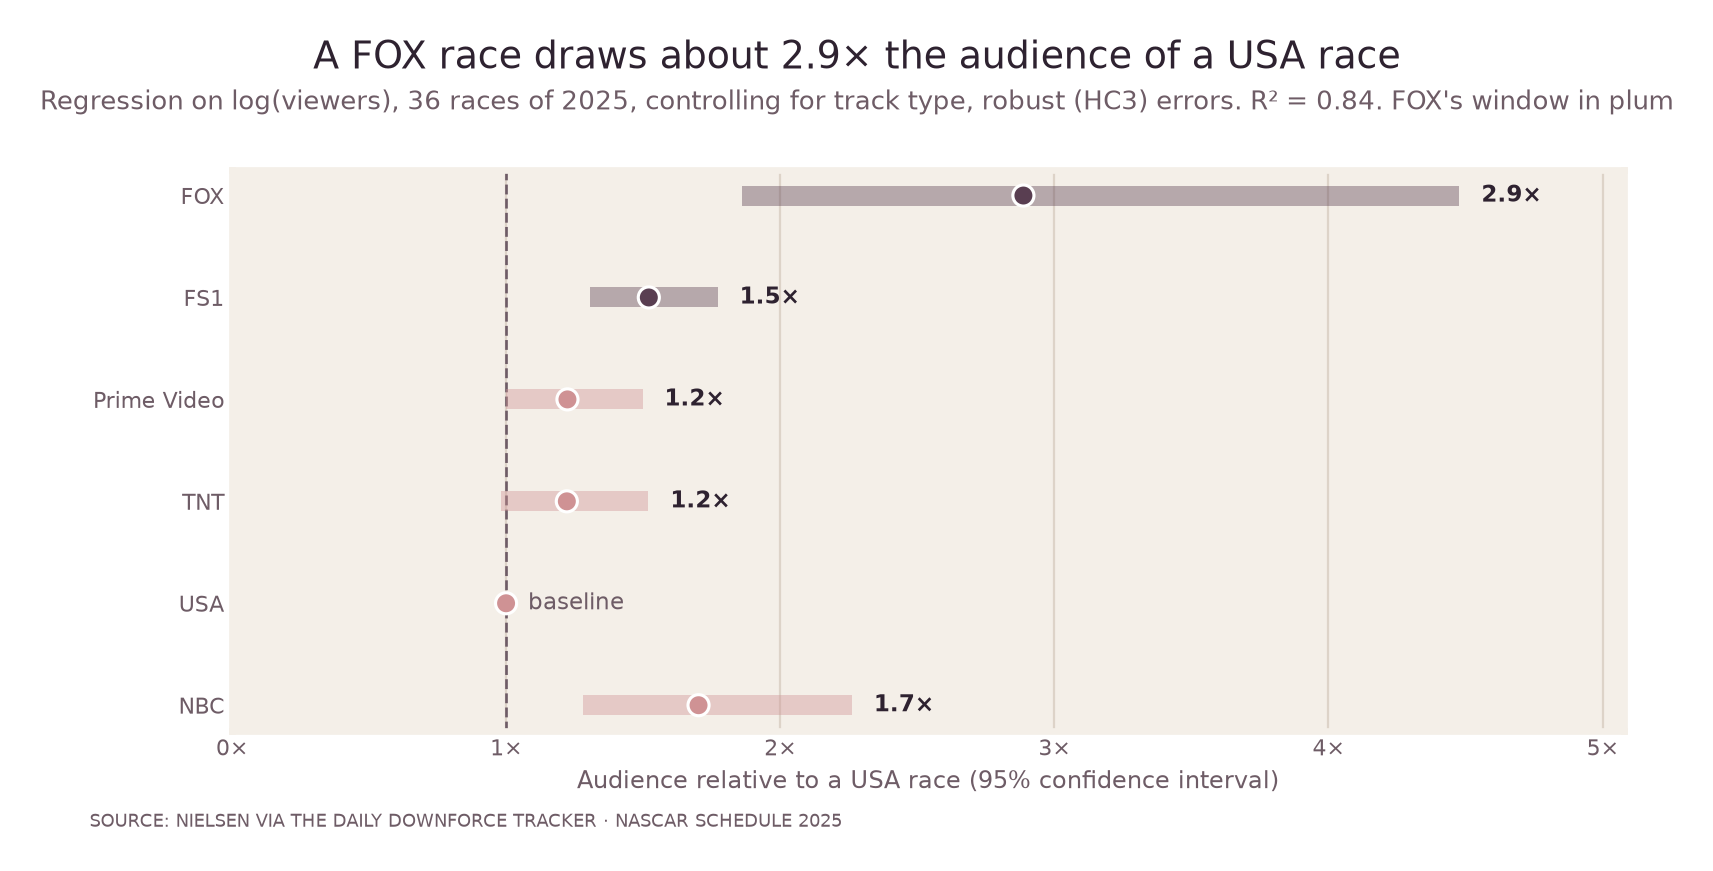

Kruskal–Wallis H = 26.9, p = 0.00006   ·   R² = 0.84   ·   FOX vs USA without the Daytona 500: 2.6×


,× USA,95% CI low,95% CI high
FOX,2.89,1.86,4.48
FS1,1.52,1.31,1.77
NBC,1.70,1.28,2.26
PRIME VIDEO,1.22,1.00,1.50
TNT,1.22,0.98,1.52


In [5]:
display(Image(str(ROOT / "images/audience_by_network.png"), width=600))
display(Image(str(ROOT / "images/audience_regression.png"), width=600))
a = S["audience_tests"]
print(f"Kruskal–Wallis H = {a['kruskal_H']:.1f}, p = {a['kruskal_p']:.5f}   ·   R² = {a['r2']:.2f}   ·   "
      f"FOX vs USA without the Daytona 500: {a['fox_vs_usa_without_daytona500']:.1f}×")
pd.DataFrame(a["vs_usa"]).T.rename(columns={"x": "× USA", "lo": "95% CI low", "hi": "95% CI high"}).round(2)

### The same pattern, network by network

One panel per broadcaster. The curve is the same shape everywhere: value falls with running position. What changes is the level, set by the audience.

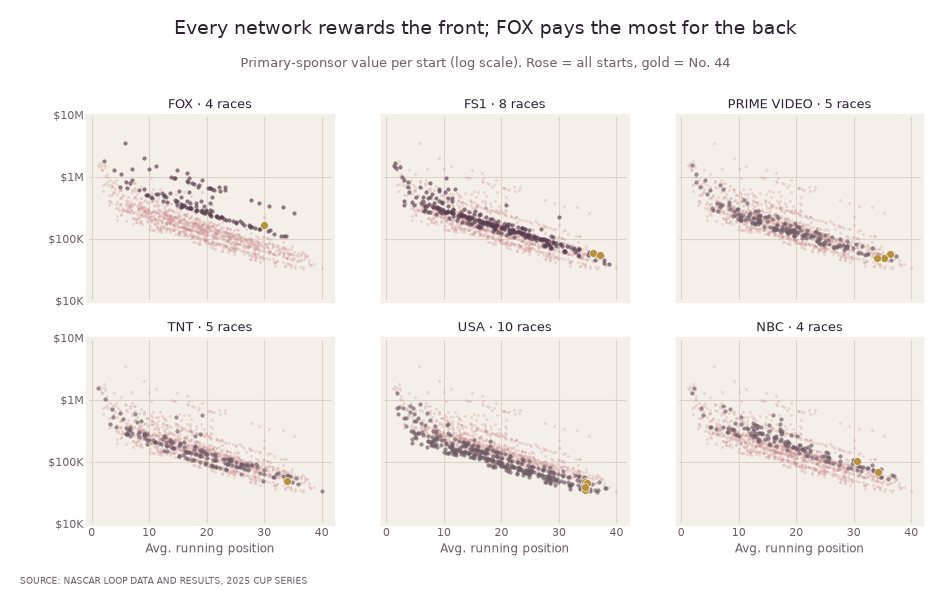

In [6]:
nets = ["FOX", "FS1", "PRIME VIDEO", "TNT", "USA", "NBC"]
ok = ~df.status.fillna("").str.contains("Accident")
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True)
for ax, n in zip(axes.flat, nets):
    sub = df[ok & (df.broadcaster == n)]
    ax.scatter(df[ok].avg_ps, df[ok].value_p50, s=4, color=CONTEXT, alpha=0.25)
    ax.scatter(sub.avg_ps, sub.value_p50, s=10, color=FIELD if n in ("FOX", "FS1") else INK_2, alpha=0.6)
    nys = sub[sub.is_ny_racing]; ax.scatter(nys.avg_ps, nys.value_p50, s=50, color=NY, edgecolor="white", zorder=3)
    ax.set_yscale("log"); ax.set_title(f"{n} · {sub.race_id.nunique()} races", fontsize=12)
    ax.set_yticks([1e4, 1e5, 1e6, 1e7]); ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f"${x/1e3:,.0f}K" if x < 1e6 else f"${x/1e6:,.0f}M"))
    ax.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
for ax in axes[1]: ax.set_xlabel("Avg. running position")
headline(fig, "Every network rewards the front; FOX pays the most for the back", "Primary-sponsor value per start (log scale). Rose = all starts, gold = No. 44")
source(fig); plt.show()

### Pricing matrix

Median value of one start by where the car runs (rows) and who broadcasts it (columns), from all 2025 starts without a crash. This is the table a partnerships team would quote from.

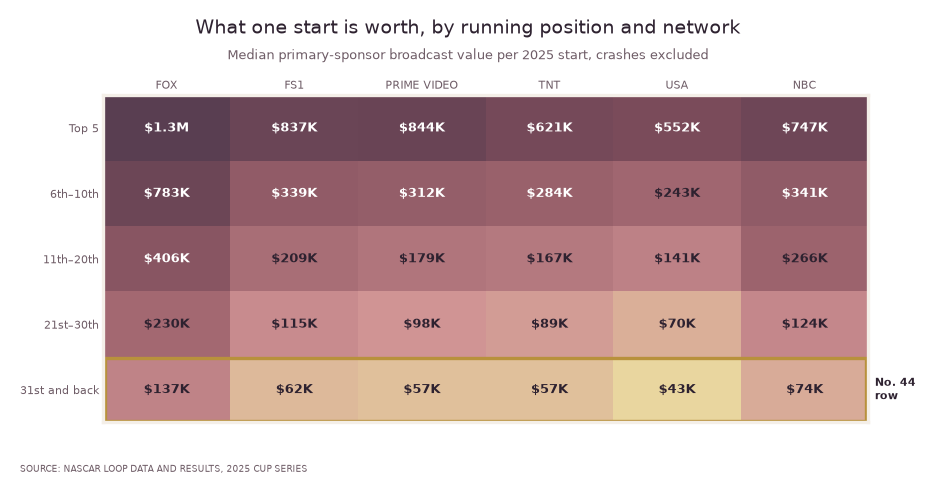

In [7]:
bins = [0, 5, 10, 20, 30, 45]; labels = ["Top 5", "6th–10th", "11th–20th", "21st–30th", "31st and back"]
m = df[ok].assign(band=pd.cut(df[ok].avg_ps, bins, labels=labels)).pivot_table(index="band", columns="broadcaster", values="value_p50", aggfunc="median", observed=False)[nets]
fig, ax = plt.subplots(figsize=(11, 5.6))
ax.imshow(np.log10(m.values), cmap=SEQ, aspect="auto")
lv = np.log10(m.values)
for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        v = m.values[i, j]; txt = f"${v/1e6:.1f}M" if v >= 1e6 else f"${v/1e3:,.0f}K"
        ax.text(j, i, txt, ha="center", va="center", fontsize=12, fontweight="bold", color="white" if lv[i, j] > lv.min() + (lv.max() - lv.min()) * 0.55 else INK)
ax.set_xticks(range(len(nets)), nets); ax.set_yticks(range(len(labels)), labels); ax.grid(False)
ax.tick_params(axis="x", top=True, bottom=False, labeltop=True, labelbottom=False)
ax.add_patch(plt.Rectangle((-0.48, 3.52), 5.96, 0.96, fill=False, edgecolor=NY, lw=3, clip_on=False))
ax.text(5.55, 4, "No. 44\nrow", color=INK, fontsize=10, fontweight="bold", va="center")
headline(fig, "What one start is worth, by running position and network", "Median primary-sponsor broadcast value per 2025 start, crashes excluded")
source(fig); plt.show()

## Finding 3 · The most valuable race is the one a part-time team can miss

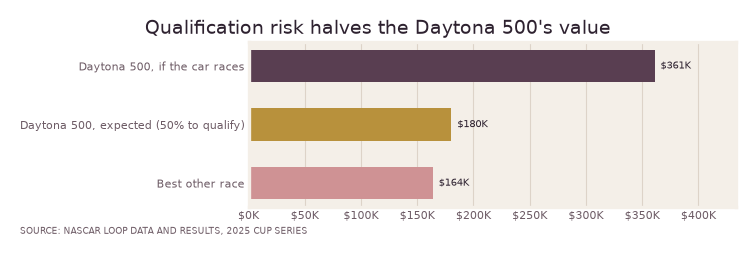

In [8]:
d = S["daytona500"]
fig, ax = plt.subplots(figsize=(7, 2.6))
vals = [d["backmarker_value_if_in"], d["expected_value"], b[b.race_id != 5546].value_p50.max()]
labs = ["Daytona 500, if the car races", "Daytona 500, expected (50% to qualify)", "Best other race"]
ax.barh(labs[::-1], vals[::-1], color=[CONTEXT, NY, FIELD], height=0.55)
for i, v in enumerate(vals[::-1]): ax.text(v, i, f"  ${v/1e3:,.0f}K", va="center", fontsize=9, color=INK)
money_axis(ax, "x", "K"); ax.set_xlim(0, max(vals) * 1.2); ax.grid(axis="y", visible=False)
headline(fig, "Qualification risk halves the Daytona 500's value")
source(fig); plt.show()

## The No. 44 race by race

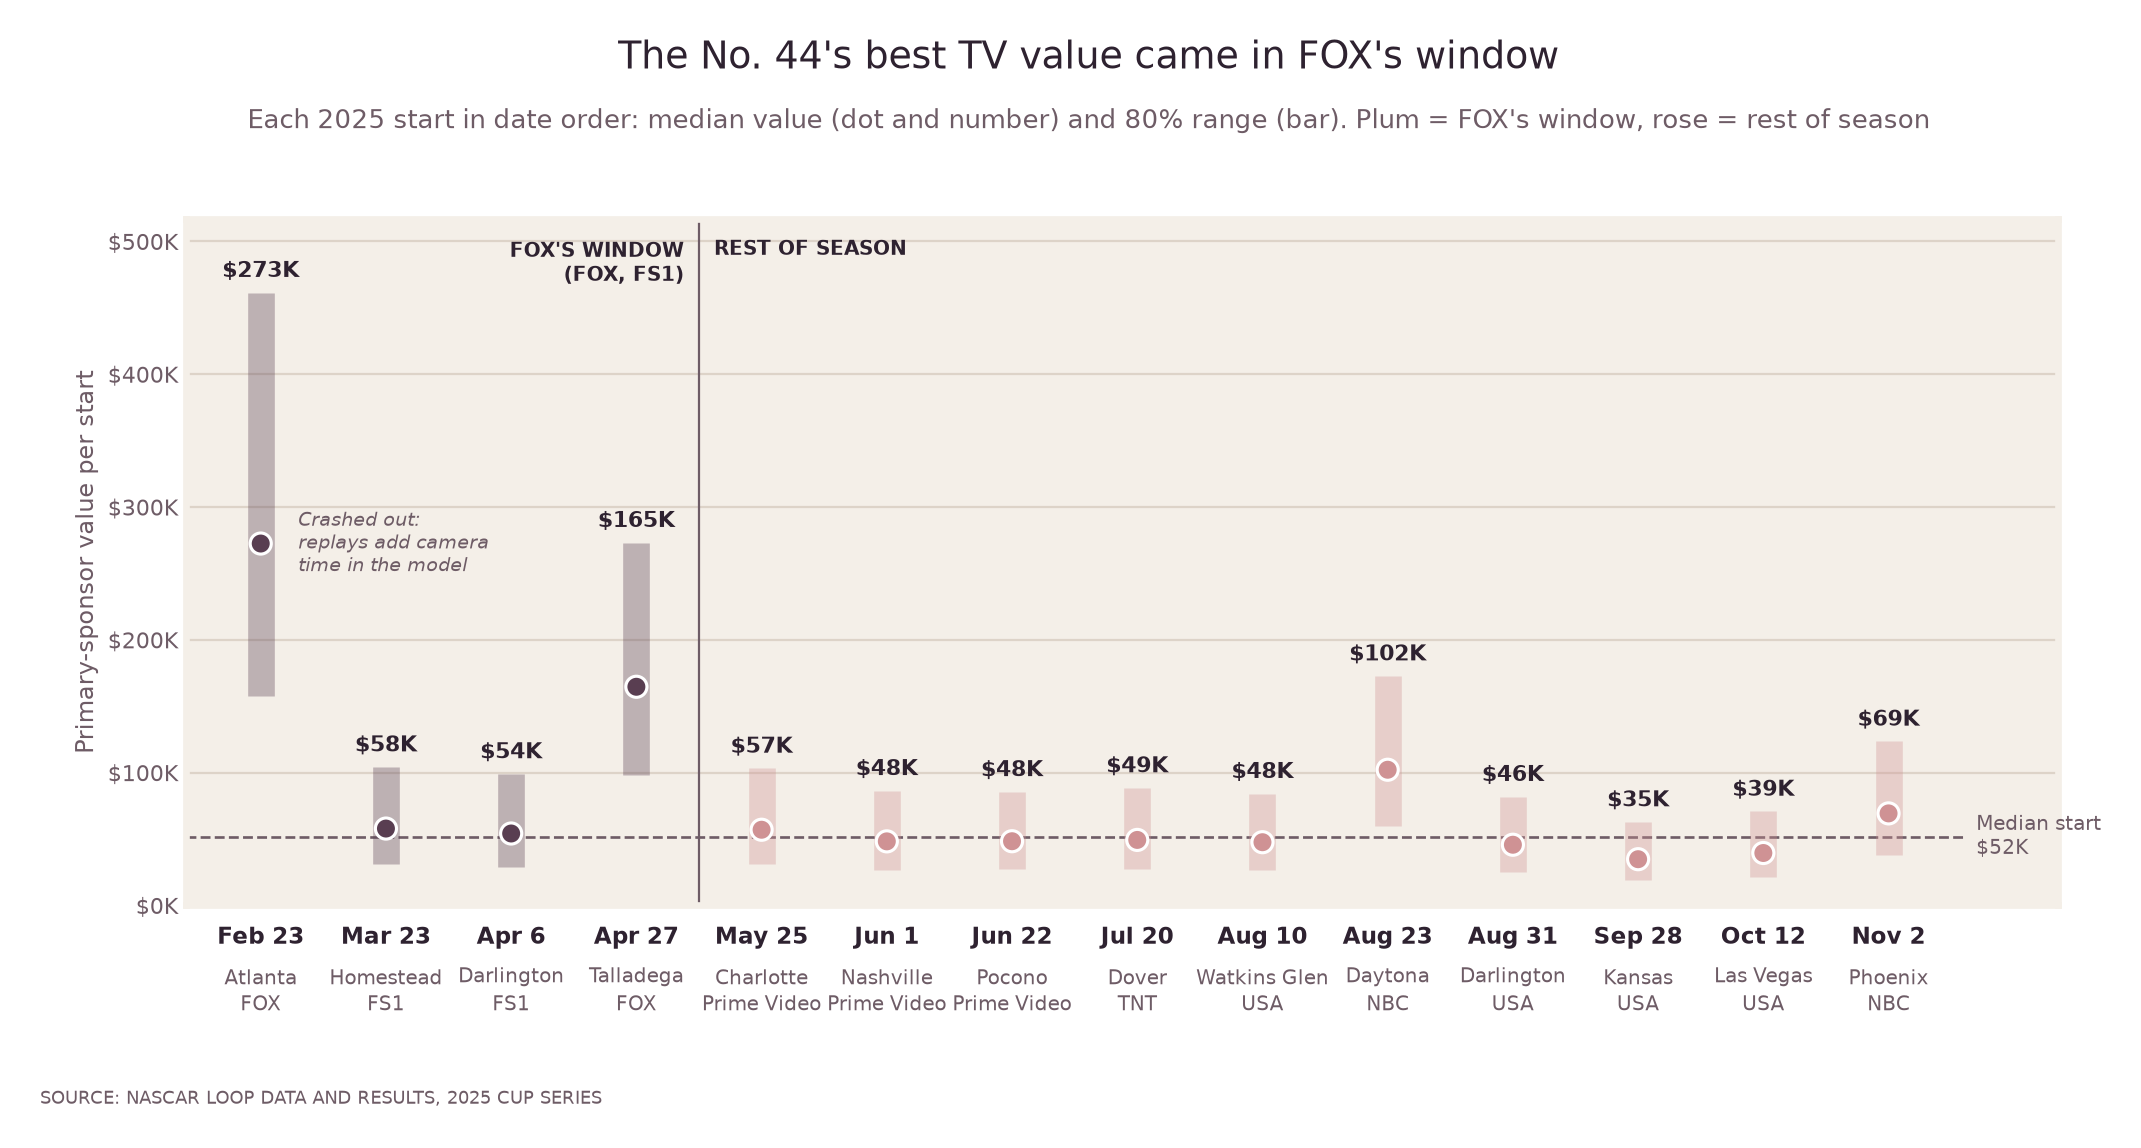

14 starts · median value per start $79K · season $1.10M (80% range $0.64M–$1.87M)


In [9]:
display(Image(str(ROOT / "images/ny44_races.png"), width=740))
n = S["ny44"]
print(f"{n['starts']} starts · median value per start ${n['per_start_median']/1e3:,.0f}K · "
      f"season ${n['season_value']['p50']/1e6:.2f}M (80% range ${n['season_value']['p10']/1e6:.2f}M–${n['season_value']['p90']/1e6:.2f}M)")

The Atlanta crash is the car's highest-value start in the model because of the crash-coverage assumption. That is the first thing the hand-coded validation sample should test.

## Pricing guide by window

In [10]:
sheet = bm.groupby("broadcaster").agg(races=("race_id", "size"), audience_m=("viewers_m", "median"),
        value_p10=("value_p10", "median"), value_p50=("value_p50", "median"), value_p90=("value_p90", "median"), clear_seconds=("clear_sec", "median"))
sheet = sheet.sort_values("value_p50", ascending=False)
sheet.style.format({"audience_m": "{:.1f}M", "value_p10": "${:,.0f}", "value_p50": "${:,.0f}", "value_p90": "${:,.0f}", "clear_seconds": "{:.0f}"})

,races,audience_m,value_p10,value_p50,value_p90,clear_seconds
broadcaster,,,,,,
FOX,4,4.4M,"$94,261","$158,071","$263,078",38
FS1,8,2.5M,"$48,941","$83,672","$142,460",37
NBC,4,2.7M,"$44,990","$77,150","$131,885",35
PRIME VIDEO,5,2.1M,"$43,411","$73,295","$122,783",41
TNT,5,2.1M,"$36,044","$63,388","$111,177",34
USA,10,1.5M,"$31,558","$54,570","$93,476",36


## Recommendations for NY Racing

1. **Price by broadcast window, not flat.** A FOX broadcast start is worth about three times a USA start.
2. **Sell the FOX window first.** The first 12 races held about half of a backmarker's season broadcast value.
3. **Sell the Daytona 500 with a written make-good**: a credit toward a later FOX-window race, or a base fee plus a bonus if the car makes the field.
4. **Check the entry list before quoting.** With four or fewer open entries, qualification risk was zero in 2025.
5. **Measure what broadcast value misses.** Any price above these numbers rests on hospitality, content, business introductions and the team's story. Track those per race.

## Limitations

Media value is not ROI. The coverage allocation is calibrated to benchmarks, not measured frame by frame. Network camera style is not modeled. Rights fees are confidential and no figure here is a contract value.